# Proyecto de Análisis de Datos: Actividades Asociadas a Ataques de Tiburón

Enfoque 

Objetivo del estudio 
Identificar qué actividades acuáticas aparecen con mayor frecuencia asociadas a ataques de tiburón   
segun los datos analizados de la web "(Global Shark Attack File)" con el objeto de desmitificar la peligrosidad de los encuentros entre humanos y tiburones mediante la estandarización de información estadística. 

 Se basa en datos que no estan en tiempo real

A través de un proceso completo de:

exploración inicial

selección de variables relevantes

limpieza y normalización

análisis exploratorio (EDA)

visualización

análisis complementario de fatalidad

buscamos comprender en qué contextos y actividades se registran más incidentes.



In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

Carga del dataset



In [71]:
df = pd.read_excel("GSAF5.xls")

In [72]:
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,14/04,2026.0,UNprovoked,Maldives,Gaafu Alif Atoll,Kooddoo,Swimming,Not stated - on honeymoon,M,?,...,Unknown,The U.S. Sun: Simon De Marchi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3rd April,2026.0,Unprovoked,Australia,South Australia,Middleton Beach Fleurieu Peninsula Adelaide,Surfing,Oliver Tokic-Bensley,M,16,...,Bronze Whaler,ABC News: The Guardian: Andrew Currie and Bob...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,26th March,2026.0,Unprovoked,Bahamas,Andros Island,Fresh Creek,Swimming,Australian woman,F,22,...,Unknown,WIC News: Melissa Michaelson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25th March,2026.0,Unprovoked,Australia,South Australia,Cape Jaffa Limestone Coast,Diving,Luke Kuhn,M,?,...,Great White Shark 3.5m (11.5ft),Bob Myatt GSAF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22nd-23rd March,2026.0,Unprovoked,Australia,NSW,Little Avalon Beach,Surfing,Unknown,M,30+,...,Unknown,Melissa Michaelson: Instagram,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Exploración inicial del dataset

In [73]:
df.shape

(7087, 23)

In [74]:
df.columns

Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7087 entries, 0 to 7086
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7087 non-null   object 
 1   Year            7085 non-null   float64
 2   Type            7069 non-null   object 
 3   Country         7037 non-null   object 
 4   State           6600 non-null   object 
 5   Location        6520 non-null   object 
 6   Activity        6504 non-null   object 
 7   Name            6869 non-null   object 
 8   Sex             6509 non-null   object 
 9   Age             4093 non-null   object 
 10  Injury          7051 non-null   object 
 11  Fatal Y/N       6526 non-null   object 
 12  Time            3560 non-null   object 
 13  Species         3956 non-null   object 
 14  Source          7067 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

In [76]:
df.isna().sum()

Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                288
href formula       293
href               291
Case Number        289
Case Number.1      290
original order     288
Unnamed: 21       7086
Unnamed: 22       7085
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(0)

Selección de columnas relevantes

Dado que nuestro objetivo es analizar las actividades asociadas a ataques de tiburón, no necesitamos trabajar con todas las columnas del dataset.

Nos enfocaremos en las siguientes variables:

- `Activity`
- `Country`
- `Year`
- `Sex`
- `Age`
- `Fatal Y/N`

Estas columnas son suficientes para responder nuestra pregunta principal y construir un análisis complementario.

In [79]:
df = df[["Activity", "Country", "Year", "Sex", "Age", "Fatal Y/N"]]

In [80]:
df.head()

,Activity,Country,Year,Sex,Age,Fatal Y/N
0,Swimming,Maldives,2026.0,M,?,N
1,Surfing,Australia,2026.0,M,16,N
2,Swimming,Bahamas,2026.0,F,22,N
3,Diving,Australia,2026.0,M,?,N
4,Surfing,Australia,2026.0,M,30+,N


Limpieza inicial de datos

En esta etapa realizamos tareas básicas de limpieza:

- eliminación de duplicados
- tratamiento de valores nulos en columnas clave
- normalización de texto

In [81]:
df = df.drop_duplicates()

In [82]:
df.isna().sum()

Activity      556
Country        48
Year            2
Sex           553
Age          2769
Fatal Y/N     555
dtype: int64

In [83]:
df = df.dropna(subset=["Activity"])

In [84]:
df["Activity"] = df["Activity"].str.lower().str.strip()

In [85]:
df["Fatal Y/N"] = df["Fatal Y/N"].astype(str).str.strip().str.upper()

In [86]:
df["Fatal Y/N"] = df["Fatal Y/N"].replace(
    ["UNKNOWN", "F", "M", "NQ", "2017", "Y X 2", "NAN"],
    np.nan
)

In [87]:
df["Fatal Y/N"].value_counts(dropna=False)

Fatal Y/N
N      4383
Y      1355
NaN     476
Name: count, dtype: int64

Exploración de la columna Activity

La columna `Activity` contiene muchas variantes textuales para referirse a actividades similares.

Antes de agruparlas, exploramos sus valores más frecuentes para entender el nivel de dispersión.

In [89]:
df["Activity"].value_counts().head(30)

Activity
swimming           1030
surfing            1002
fishing             467
spearfishing        378
wading              177
bathing             161
diving              148
snorkeling          136
standing            113
scuba diving        105
body boarding        70
boogie boarding      59
body surfing         55
kayaking             42
free diving          35
treading water       33
fell overboard       31
pearl diving         25
surf skiing          24
windsurfing          20
floating             18
walking              17
canoeing             16
kayak fishing        15
shark fishing        15
surf fishing         14
playing              14
surf-skiing          13
rowing               13
sea disaster         13
Name: count, dtype: int64

Estandarización de actividades

Para facilitar el análisis, agrupamos actividades similares dentro de categorías más amplias.

Por ejemplo:

- surfing, surf, surf-skiing → **Surf**
- swimming, bathing → **Natación**
- fishing, spearfishing → **Pesca**

Esto nos permitirá trabajar con categorías más limpias, comparables y visualmente más claras.

In [91]:
def agrupar_actividad(texto):
    if pd.isna(texto):
        return "Otros"
    
    texto = str(texto).lower().strip()
    
    if re.search(r"surf", texto):
        return "Surf"
    elif re.search(r"swim|bathing", texto):
        return "Natación"
    elif re.search(r"fish", texto):
        return "Pesca"
    elif re.search(r"dive|diving|scuba", texto):
        return "Buceo"
    elif re.search(r"snork", texto):
        return "Snorkel"
    elif re.search(r"boat|sail|kayak|canoe|paddle", texto):
        return "Navegación"
    elif re.search(r"wading", texto):
        return "Caminando en el agua"
    else:
        return "Otros"

In [92]:
df["activity_group"] = df["Activity"].apply(agrupar_actividad)

In [93]:
df[["Activity", "activity_group"]].head(20)

,Activity,activity_group
0,swimming,Natación
1,surfing,Surf
2,swimming,Natación
3,diving,Buceo
4,surfing,Surf
5,surfing,Surf
6,swimming,Natación
7,wing foiling,Otros
8,snorkeling,Snorkel
9,wing foiling,Otros


In [94]:
df["activity_group"].value_counts()

activity_group
Natación                1417
Surf                    1309
Pesca                   1243
Otros                   1147
Buceo                    558
Navegación               213
Caminando en el agua     187
Snorkel                  140
Name: count, dtype: int64

Análisis principal: actividades agrupadas con más ataques

Una vez estandarizadas las actividades, analizamos qué grupos de actividad aparecen con mayor frecuencia asociados a ataques de tiburón registrados.

In [95]:
activity_counts = df.groupby("activity_group").size().sort_values(ascending=False)
activity_counts

activity_group
Natación                1417
Surf                    1309
Pesca                   1243
Otros                   1147
Buceo                    558
Navegación               213
Caminando en el agua     187
Snorkel                  140
dtype: int64

Visualización del análisis principal

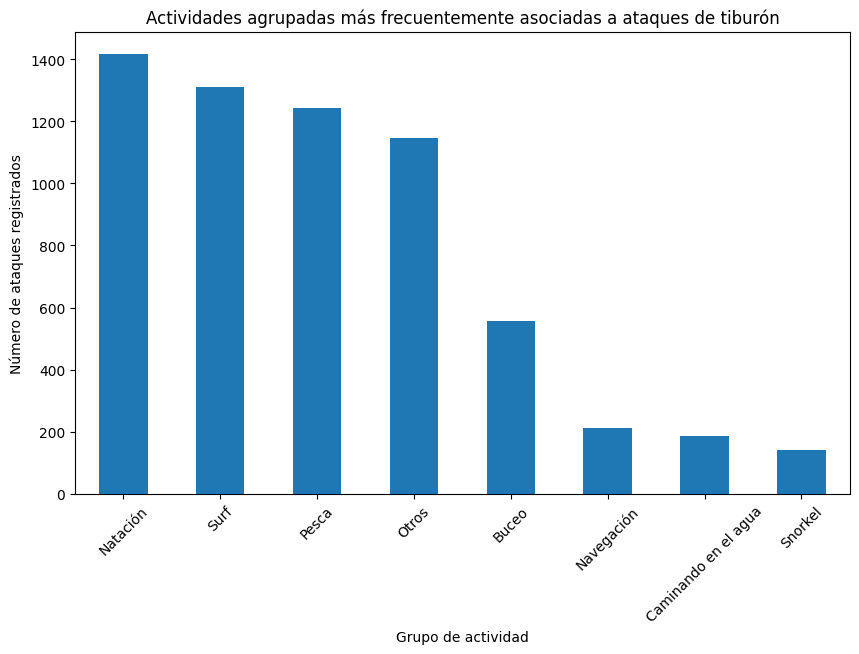

In [96]:
activity_counts.plot(kind="bar", figsize=(10,6))
plt.title("Actividades agrupadas más frecuentemente asociadas a ataques de tiburón")
plt.xlabel("Grupo de actividad")
plt.ylabel("Número de ataques registrados")
plt.xticks(rotation=45)
plt.show()

Análisis complementario: actividad agrupada vs fatalidad

Además del análisis principal, exploramos la relación entre el tipo de actividad y si el ataque fue fatal o no fatal.

Esto añade una capa adicional de contexto al análisis.

In [97]:
activity_fatality = df.groupby(["activity_group", "Fatal Y/N"]).size().reset_index(name="cantidad")
activity_fatality

,activity_group,Fatal Y/N,cantidad
0,Buceo,N,359
1,Buceo,Y,135
2,Caminando en el agua,N,158
3,Caminando en el agua,Y,17
4,Natación,N,774
5,Natación,Y,510
6,Navegación,N,129
7,Navegación,Y,59
8,Otros,N,701
9,Otros,Y,348


In [99]:
tabla_fatal = activity_fatality.pivot(index="activity_group", columns="Fatal Y/N", values="cantidad").fillna(0)
tabla_fatal

Fatal Y/N,N,Y
activity_group,,
Buceo,359,135
Caminando en el agua,158,17
Natación,774,510
Navegación,129,59
Otros,701,348
Pesca,988,173
Snorkel,114,20
Surf,1160,93


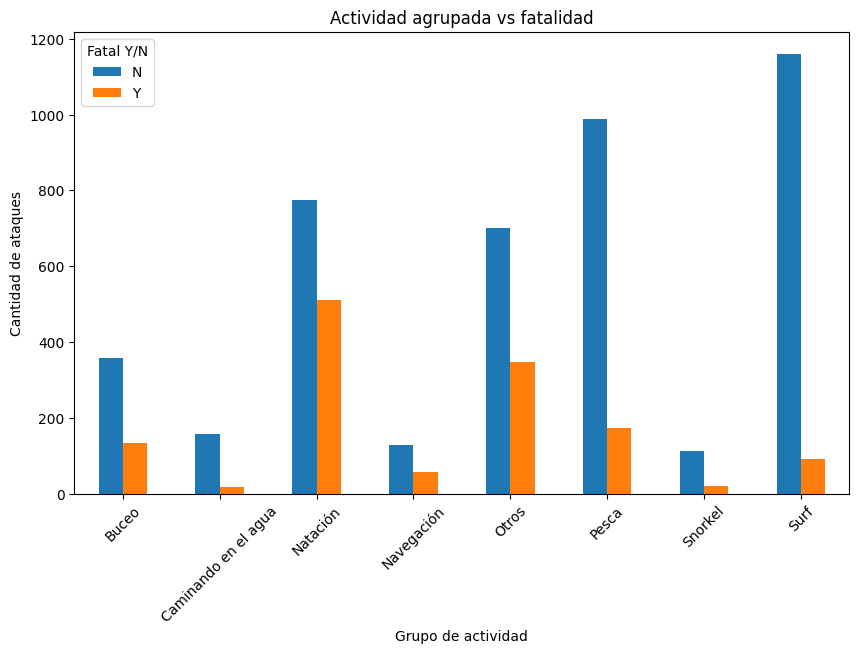

In [100]:
tabla_fatal.plot(kind="bar", figsize=(10,6))
plt.title("Actividad agrupada vs fatalidad")
plt.xlabel("Grupo de actividad")
plt.ylabel("Cantidad de ataques")
plt.xticks(rotation=45)
plt.show()

Hallazgos principales

A partir del análisis exploratorio realizado, observamos lo siguiente:

- La variable `Activity` contenía una gran dispersión de valores, por lo que su agrupación fue necesaria para facilitar el análisis.
- Algunas categorías, como **Surf**, **Natación** y **Pesca**, concentran gran parte de los ataques registrados.
- En el análisis de fatalidad, se observa que la mayoría de los ataques registrados no fueron fatales.
- La combinación entre limpieza, agrupación y visualización permitió transformar una columna caótica en información útil y comprensible.

Conclusión

Este proyecto permitió analizar qué tipos de actividades acuáticas aparecen con mayor frecuencia asociadas a ataques de tiburón registrados en el dataset.

Para ello, se llevó a cabo un proceso de:

- exploración inicial del dataset
- detección de valores nulos y duplicados
- selección de columnas relevantes
- limpieza y normalización de texto
- agrupación de actividades en categorías comparables
- análisis exploratorio con `groupby()`
- visualización de resultados

La estandarización de actividades fue una parte clave del proyecto, ya que permitió reducir cientos de valores distintos a un conjunto pequeño de categorías más claras y útiles para el análisis.

Los resultados muestran que ciertas actividades aparecen con mayor frecuencia en los registros de ataques. Sin embargo, es importante recordar que este análisis refleja la frecuencia dentro del dataset y no el riesgo absoluto real de cada actividad en la vida real.